In [1]:
# Import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


df = pd.read_csv('world_bank_data_2025.csv')
df.head(5)

,country_name,country_id,year,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Government Expense (% of GDP),Government Revenue (% of GDP),Tax Revenue (% of GDP),Gross National Income (USD),Public Debt (% of GDP)
0,Aruba,aw,2010,2.078141,2.453597e+09,24093.14015,NaN,11.666131,-1.223407,-2.733457,-18.752537,NaN,NaN,NaN,2.313385e+09,NaN
1,Aruba,aw,2011,4.316297,2.637859e+09,25712.38430,NaN,4.801974,4.005674,3.369237,-9.877656,NaN,NaN,NaN,2.391841e+09,NaN
2,Aruba,aw,2012,0.627472,2.615208e+09,25119.66554,NaN,8.200875,0.184033,-1.040800,3.473451,NaN,NaN,NaN,2.499118e+09,NaN
3,Aruba,aw,2013,-2.372065,2.727850e+09,25813.57673,NaN,10.709709,-1.995948,6.431483,-11.813206,NaN,NaN,NaN,2.563517e+09,NaN
4,Aruba,aw,2014,0.421441,2.790850e+09,26129.83906,NaN,3.213869,3.958897,-1.586575,-4.658577,NaN,NaN,NaN,2.688102e+09,NaN


In [2]:
# selecting the target countries that will be used in this project

df_without2025 = df[(df['year'] < 2024) & (df['country_name'])].copy()
target_countries = [
    # Europe
    'Albania', 'Austria', 'Belarus', 'Belgium', 'Bosnia and Herzegovina',
    'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark',
    'Estonia', 'Finland', 'France', 'Germany',
    'Greece', 'Hungary', 'Iceland', 'Ireland', 'Italy', 'Latvia',
    'Lithuania', 'Luxembourg', 'Malta', 'Moldova',
    'Montenegro', 'Netherlands', 'North Macedonia', 'Norway', 'Poland', 'Portugal',
    'Romania', 'San Marino', 'Serbia', 'Slovak Republic', 'Slovenia', 'Spain',
    'Sweden', 'Switzerland', 'Ukraine', 'United Kingdom',

    # Specified Countries
    'Canada','United States','China', 'Japan', 'Korea, Rep.', 'Russian Federation'
]

df_target = df_without2025[df_without2025['country_name'].isin(target_countries)].copy()

<h2 style="font-size:25px; color:green;">Data Selection:</h2> <h4> European Countries and Major Powers</h4>

**Note:** The selection excludes some European countries that had too many missing values to be reliably handled.

In [3]:
# Displaying the count of missing data for each country

missing_values = df_target.isnull().sum(axis=1).groupby(df_target['country_name']).sum()
missing_values_sorted = missing_values.sort_values(ascending=False)
pd.set_option('display.max_rows', None)

print(missing_values_sorted)

country_name
Montenegro                56
San Marino                39
Japan                     36
Germany                   31
Serbia                    30
Poland                    28
Luxembourg                28
Finland                   28
Denmark                   28
Latvia                    28
Cyprus                    28
China                     28
Slovenia                  28
Portugal                  28
Malta                     24
Netherlands               24
North Macedonia           20
Sweden                    18
Belgium                   18
Slovak Republic           18
Ireland                   18
Norway                    17
Czechia                   17
Italy                     14
Austria                   14
Lithuania                 14
France                    14
Estonia                   14
Spain                     14
Greece                    14
Croatia                    9
United Kingdom             9
Albania                    6
Canada                     6
U

In [4]:
# Displaying the count of missing data for each feature

df_target.isnull().sum().sort_values(ascending=False)

Interest Rate (Real, %)            335
Public Debt (% of GDP)             274
Government Expense (% of GDP)       42
Government Revenue (% of GDP)       41
Tax Revenue (% of GDP)              41
Unemployment Rate (%)               16
Current Account Balance (% GDP)      8
Gross National Income (USD)          8
Inflation (CPI %)                    2
GDP (Current USD)                    1
GDP per Capita (Current USD)         1
Inflation (GDP Deflator, %)          1
GDP Growth (% Annual)                1
country_name                         0
country_id                           0
year                                 0
dtype: int64

In [5]:
# Displaying the descriptive statistics for the dataset

df_target.describe()

,year,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Government Expense (% of GDP),Government Revenue (% of GDP),Tax Revenue (% of GDP),Gross National Income (USD),Public Debt (% of GDP)
count,644.000000,642.000000,6.430000e+02,643.000000,628.000000,309.000000,643.000000,643.000000,636.000000,602.000000,603.000000,603.000000,6.360000e+02,370.000000
mean,2016.500000,3.257107,1.363237e+12,33229.353631,8.447836,2.017889,3.675131,2.158943,0.073700,35.623214,33.372566,19.466008,1.381400e+12,75.010667
std,4.034262,5.068905,3.521522e+12,26043.375181,5.654019,5.165658,6.050658,3.867383,5.719571,8.558344,7.862258,5.499449,3.560035e+12,49.311923
min,2010.000000,-2.096998,1.419401e+09,2094.473877,0.785000,-33.489025,-10.619158,-28.758584,-25.933503,16.071319,10.956237,7.700873,1.394335e+09,7.168858
25%,2013.000000,0.815196,4.336157e+10,12689.810635,4.685250,0.337002,1.033646,0.809436,-2.893138,31.039009,28.648813,15.620397,4.350410e+10,38.068928
50%,2016.500000,2.004323,2.270000e+11,26409.628590,6.801500,2.537232,2.064074,2.291506,0.158470,36.217224,33.960955,20.077804,2.180000e+11,63.667236
75%,2020.000000,3.666690,9.075000e+11,48665.033500,10.104250,4.418991,4.398907,3.915464,3.235080,41.144963,38.989670,23.230609,8.945000e+11,98.242950
max,2023.000000,59.219736,2.770000e+13,133711.794400,33.135000,17.819805,75.241667,24.615570,28.752956,66.463888,56.533349,37.612850,2.760000e+13,249.366027


In [6]:
# Dropping features that have many missing values

columns_to_drop = [
    'Interest Rate (Real, %)',
    'Public Debt (% of GDP)',
    'country_id'
]
df_target.drop(columns=columns_to_drop, inplace=True)

In [7]:
# Displaying the count of missing data for each country and feature

missing = df_target.isnull().groupby(df_target['country_name']).sum()
total_missing = missing.sum(axis=1)
order = total_missing.sort_values(ascending=False).index
missing_sorted = missing.reindex(order)

missing_values_schedule = (df_target.groupby('country_name').apply(lambda x: x.drop(columns=['country_name']).isnull().sum()))
missing_values_schedule


C:\Users\sedra\AppData\Local\Temp\ipykernel_9144\1912794607.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_values_schedule = (df_target.groupby('country_name').apply(lambda x: x.drop(columns=['country_name']).isnull().sum()))


,year,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Government Expense (% of GDP),Government Revenue (% of GDP),Tax Revenue (% of GDP),Gross National Income (USD)
country_name,,,,,,,,,,,,
Albania,0,0,0,0,0,0,0,0,1,1,1,0
Austria,0,0,0,0,0,0,0,0,0,0,0,0
Belarus,0,0,0,0,0,0,0,0,0,0,0,0
Belgium,0,0,0,0,0,0,0,0,1,1,1,0
Bosnia and Herzegovina,0,0,0,0,0,0,0,0,0,0,0,0
Bulgaria,0,0,0,0,0,0,0,0,0,0,0,0
Canada,0,0,0,0,0,0,0,0,0,0,0,0
China,0,0,0,0,0,0,0,0,14,0,0,0
Croatia,0,0,0,0,0,0,0,0,0,0,0,0


In [8]:
# Preprocessing Missing Data

df_target = df_target.groupby('country_name', group_keys=False).apply(lambda x: x.ffill().bfill()).reset_index(drop=True)
original_countries = df_target['country_name'].copy()

le = LabelEncoder()
df_target['country_name_encoded'] = le.fit_transform(df_target['country_name'])

scaler = MinMaxScaler()
numeric_cols = df_target.select_dtypes(include=[np.number]).columns.tolist()

df_scaled = df_target.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df_target[numeric_cols])

imputer = KNNImputer(n_neighbors=3, weights='uniform')
cols_for_imputation = [c for c in df_scaled.columns if c != 'country_name']
imputed_values = imputer.fit_transform(df_scaled[cols_for_imputation])
df_imputed_scaled = pd.DataFrame(imputed_values, columns=cols_for_imputation, index=df_target.index)

df_final_values = scaler.inverse_transform(df_imputed_scaled)
df_final = pd.DataFrame(df_final_values, columns=cols_for_imputation, index=df_target.index)

df_final['country_name'] = original_countries

if 'country_name_encoded' in df_final.columns:
    df_final.drop(columns=['country_name_encoded'], inplace=True)

df_final['year'] = df_final['year'].round().astype(int)
cols_order = ['country_name'] + [c for c in df_final.columns if c != 'country_name']
df_target = df_final[cols_order].copy()

C:\Users\sedra\AppData\Local\Temp\ipykernel_9144\3136186717.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_target = df_target.groupby('country_name', group_keys=False).apply(lambda x: x.ffill().bfill()).reset_index(drop=True)


<h3 style="font-size:25px; color:green;">Missing Data Imputation </h3>

We used **fill** methods for countries that only have **1 or 2** missing data in each column.

Then use the **KNNimputer** to deal with countries that do not have any data in a specific feature by finding the nearest neighbors (countries) to impute the missing values.

In [9]:
# Checking for missing data after

df_target.isnull().sum().sort_values(ascending=False)

country_name                       0
year                               0
Inflation (CPI %)                  0
GDP (Current USD)                  0
GDP per Capita (Current USD)       0
Unemployment Rate (%)              0
Inflation (GDP Deflator, %)        0
GDP Growth (% Annual)              0
Current Account Balance (% GDP)    0
Government Expense (% of GDP)      0
Government Revenue (% of GDP)      0
Tax Revenue (% of GDP)             0
Gross National Income (USD)        0
dtype: int64

In [10]:
# Creating log-transformed features for GDP per Capita, GDP, GNI for use in the model.

wealth = [
    'GDP (Current USD)',
    'Gross National Income (USD)',
    'GDP per Capita (Current USD)'
]

for col in wealth:
    new_col_name = f'Log({col})'
    df_target[new_col_name] = np.log(df_target[col])

df_target.head(5)

,country_name,year,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Government Expense (% of GDP),Government Revenue (% of GDP),Tax Revenue (% of GDP),Gross National Income (USD),Log(GDP (Current USD)),Log(Gross National Income (USD)),Log(GDP per Capita (Current USD))
0,Albania,2010,3.627101,1.192693e+10,4094.349686,14.086,4.493143,3.706938,-11.365866,23.011107,23.900319,18.022013,1.180777e+10,23.202064,23.192024,8.317363
1,Albania,2011,3.428071,1.289076e+10,4437.141161,13.481,2.314744,2.545406,-12.933101,23.011107,23.900319,18.022013,1.289410e+10,23.279777,23.280036,8.397766
2,Albania,2012,2.031593,1.231983e+10,4247.631343,13.376,1.042715,1.417243,-10.200176,23.007591,23.050710,17.483234,1.222807e+10,23.234476,23.227000,8.354117
3,Albania,2013,1.937621,1.277622e+10,4413.063383,15.866,0.288746,1.002018,-9.274188,24.160773,22.304950,16.503271,1.299654e+10,23.270852,23.287949,8.392324
4,Albania,2014,1.625865,1.322815e+10,4578.633208,18.055,1.549917,1.774449,-10.775399,24.382665,24.525098,18.301936,1.334942e+10,23.305613,23.314739,8.429156


<h3 style="font-size:25px; color:green;">Rationale for Log Transformation</h3>

we used log for three features:

* Gross National Income (USD)
* GDP (Current USD)
* GDP per Capita (Current USD)

To scale all countries in a specific range and avoid the big gaps between small and big countries this helps in dealing with the power-law distribution typical of economic variables.

<h2 style="font-size:30px; color:green;">Outliers</h2>

In [11]:
# Checking for the total number of outliers for each feature

numeric_cols = df_target.select_dtypes(include=np.number).columns.drop('year', errors='ignore')
for column in numeric_cols:
    Q1 = df_target[column].quantile(0.25)
    Q3 = df_target[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_count = len(df_target[
        (df_target[column] < lower_bound) | (df_target[column] > upper_bound)
    ])

    print(f"'{column}': {outliers_count}")

'Inflation (CPI %)': 61
'GDP (Current USD)': 89
'GDP per Capita (Current USD)': 19
'Unemployment Rate (%)': 45
'Inflation (GDP Deflator, %)': 52
'GDP Growth (% Annual)': 57
'Current Account Balance (% GDP)': 27
'Government Expense (% of GDP)': 6
'Government Revenue (% of GDP)': 5
'Tax Revenue (% of GDP)': 4
'Gross National Income (USD)': 92
'Log(GDP (Current USD))': 0
'Log(Gross National Income (USD))': 0
'Log(GDP per Capita (Current USD))': 0


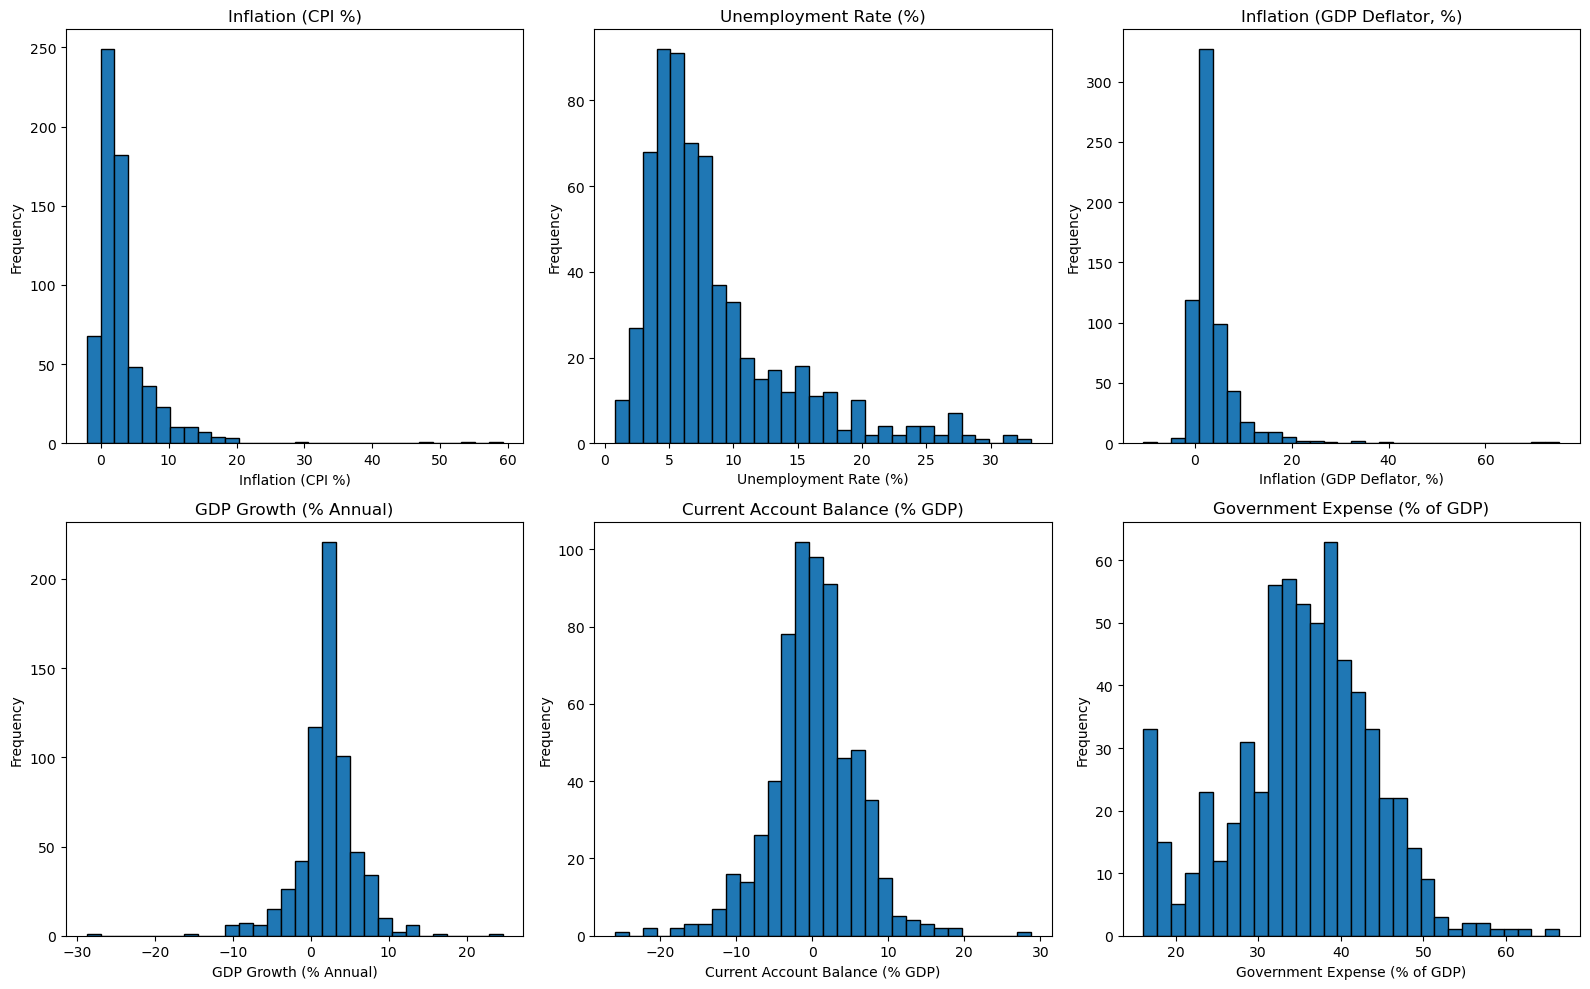

In [12]:
cols1 = [
    "Inflation (CPI %)",
    "Unemployment Rate (%)",
    "Inflation (GDP Deflator, %)",
    "GDP Growth (% Annual)",
    "Current Account Balance (% GDP)",
    "Government Expense (% of GDP)"
]

plt.figure(figsize=(16, 10))

for i, col in enumerate(cols1, 1):
    plt.subplot(2, 3, i)
    plt.hist(df_target[col], bins=30, edgecolor='black')
    plt.title(f"{col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


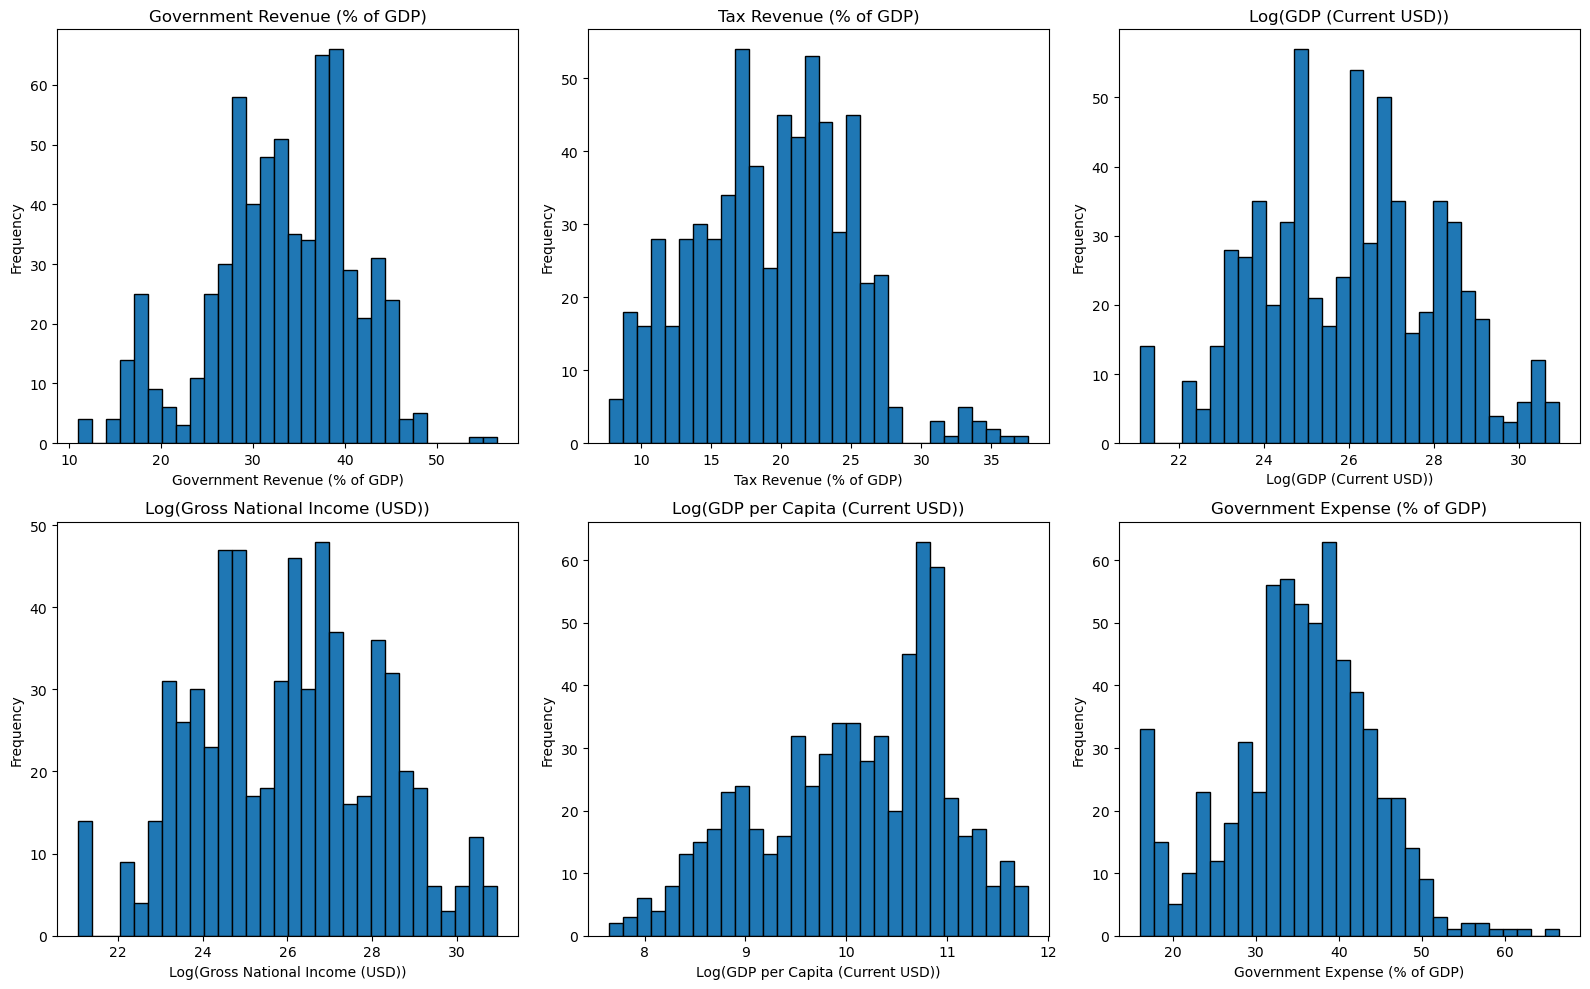

In [13]:
cols2 = [
    "Government Revenue (% of GDP)",
    "Tax Revenue (% of GDP)",
    "Log(GDP (Current USD))",
    "Log(Gross National Income (USD))",
    "Log(GDP per Capita (Current USD))",
    "Government Expense (% of GDP)" 
]

plt.figure(figsize=(16, 10))

for i, col in enumerate(cols2, 1):
    plt.subplot(2, 3, i)
    plt.hist(df_target[col], bins=30, edgecolor='black')
    plt.title(f"{col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


<h2>While some outliers exist, they represent real economic data (not errors) and are therefore retained in the analysis instead of being dropped.</h2>

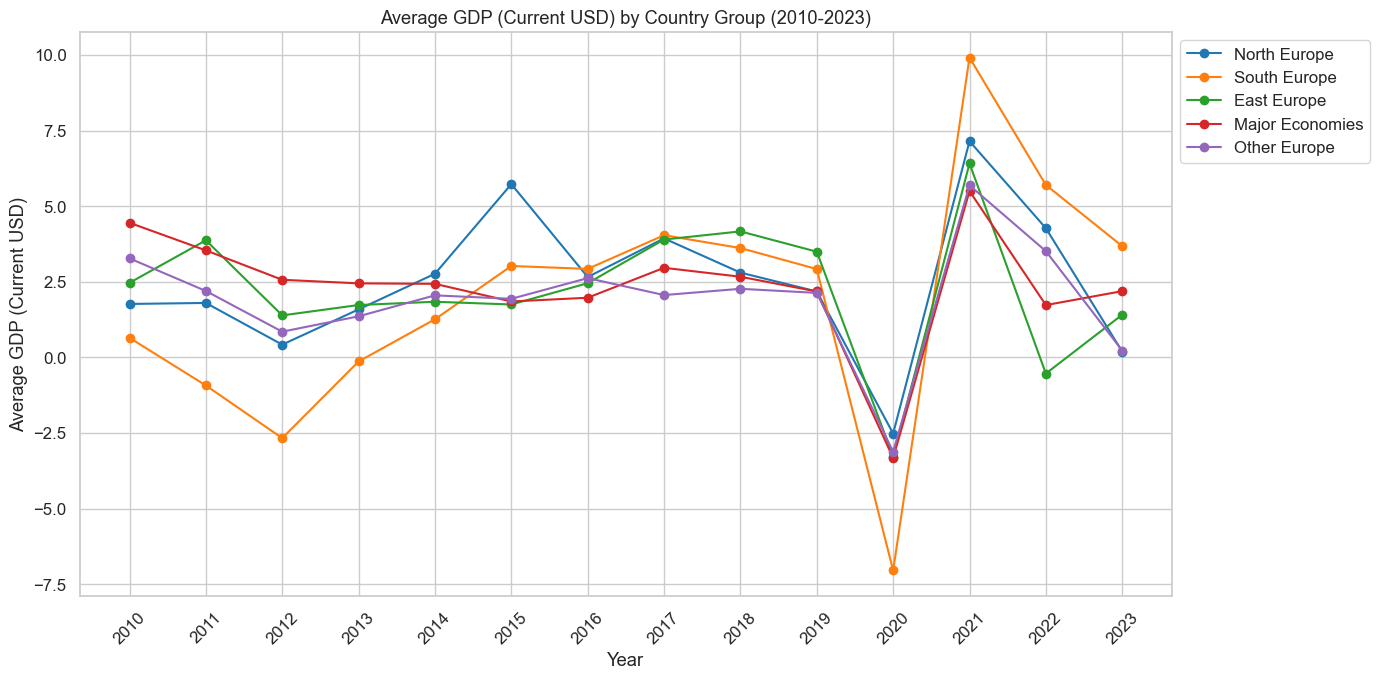

In [14]:
# Compute average GDP per group per year

north_europe = ['Denmark','Finland','Iceland','Ireland','Norway','Sweden','United Kingdom']
south_europe = ['Albania','Bosnia and Herzegovina','Croatia','Cyprus','Greece','Italy','Malta','Montenegro','Portugal','San Marino','Slovenia','Spain']
east_europe = ['Belarus','Bulgaria','Czechia','Estonia','Hungary','Latvia','Lithuania','Moldova','North Macedonia','Poland','Romania','Serbia','Slovak Republic','Ukraine']
major_economies = ['United States','China','Japan','Germany','France','Canada','Russian Federation']
other_europe = [c for c in target_countries if c not in (north_europe + south_europe + east_europe + major_economies)]

groups = {
    'North Europe': north_europe,
    'South Europe': south_europe,
    'East Europe': east_europe,
    'Major Economies': major_economies,
    'Other Europe': other_europe
}

avg_gdp = pd.DataFrame({'year': sorted(df_target['year'].unique())})
for group_name, countries in groups.items():
    group_data = df_target[df_target['country_name'].isin(countries)]
    avg_gdp[group_name] = group_data.groupby('year')['GDP Growth (% Annual)'].mean().values

plt.figure(figsize=(14,7))
sns.set(style="whitegrid", palette="tab10", font_scale=1.1)
for group_name in groups.keys():
    plt.plot(avg_gdp['year'], avg_gdp[group_name], marker='o', label=group_name)

plt.title('Average GDP (Current USD) by Country Group (2010-2023)')
plt.xlabel('Year')
plt.ylabel('Average GDP (Current USD)')
plt.xticks(range(2010, 2024, 1), rotation=45)
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

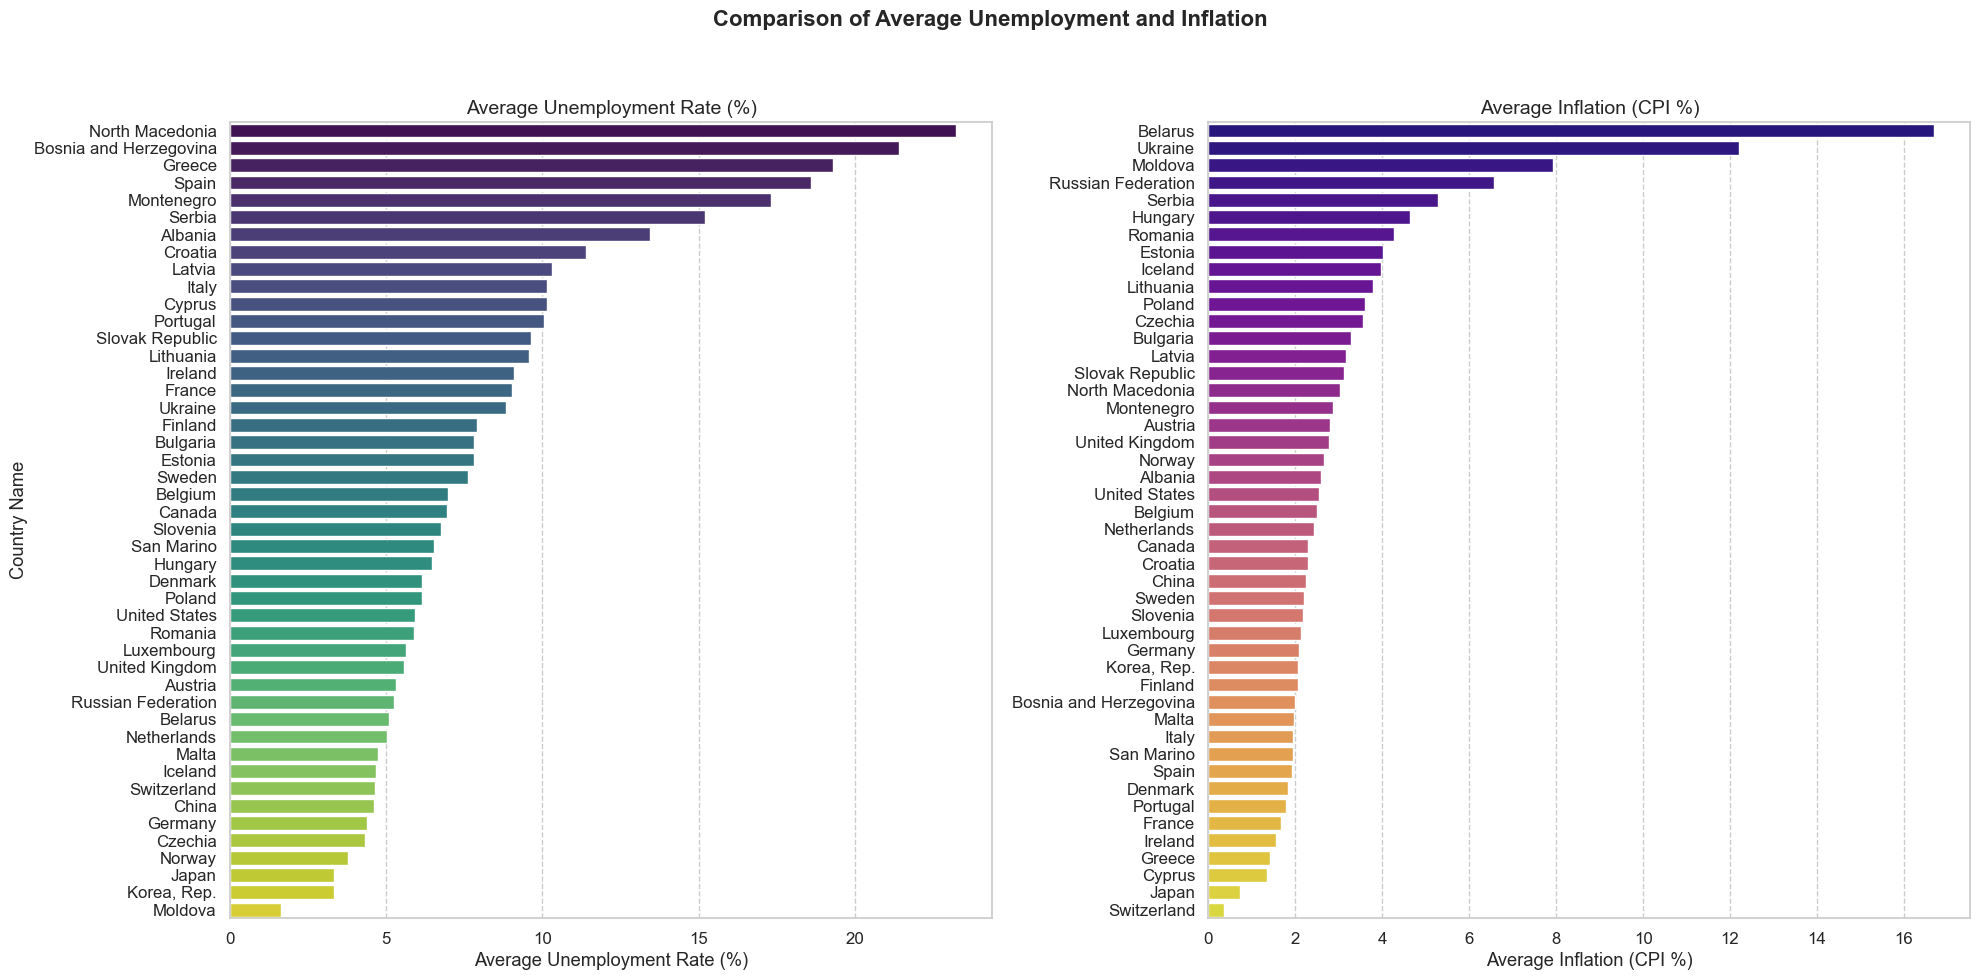

In [15]:
# The Unemployment Rate (%) and Inflation (CPI %) barplots process

unemployment_avg = df_target.groupby('country_name')['Unemployment Rate (%)'].mean().sort_values(ascending=False).reset_index()
inflation_avg = df_target.groupby('country_name')['Inflation (CPI %)'].mean().sort_values(ascending=False).reset_index()


fig, axes = plt.subplots(1, 2, figsize=(20, 10))
plt.suptitle('Comparison of Average Unemployment and Inflation', fontsize=16, fontweight='bold')

# average unemployment rate
sns.barplot(data=unemployment_avg, x='Unemployment Rate (%)', y='country_name', hue='country_name', palette='viridis', ax=axes[0])
axes[0].set_title('Average Unemployment Rate (%)', fontsize=14)
axes[0].set_xlabel('Average Unemployment Rate (%)')
axes[0].set_ylabel('Country Name')
axes[0].grid(axis='x', linestyle='--')
if axes[0].get_legend():
    axes[0].legend_.remove()


# average inflation CPI
sns.barplot(data=inflation_avg, x='Inflation (CPI %)', y='country_name', hue='country_name', palette='plasma', ax=axes[1])
axes[1].set_title('Average Inflation (CPI %)', fontsize=14)
axes[1].set_xlabel('Average Inflation (CPI %)')
axes[1].set_ylabel('')
axes[1].grid(axis='x', linestyle='--')
if axes[1].get_legend():
    axes[1].legend_.remove()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

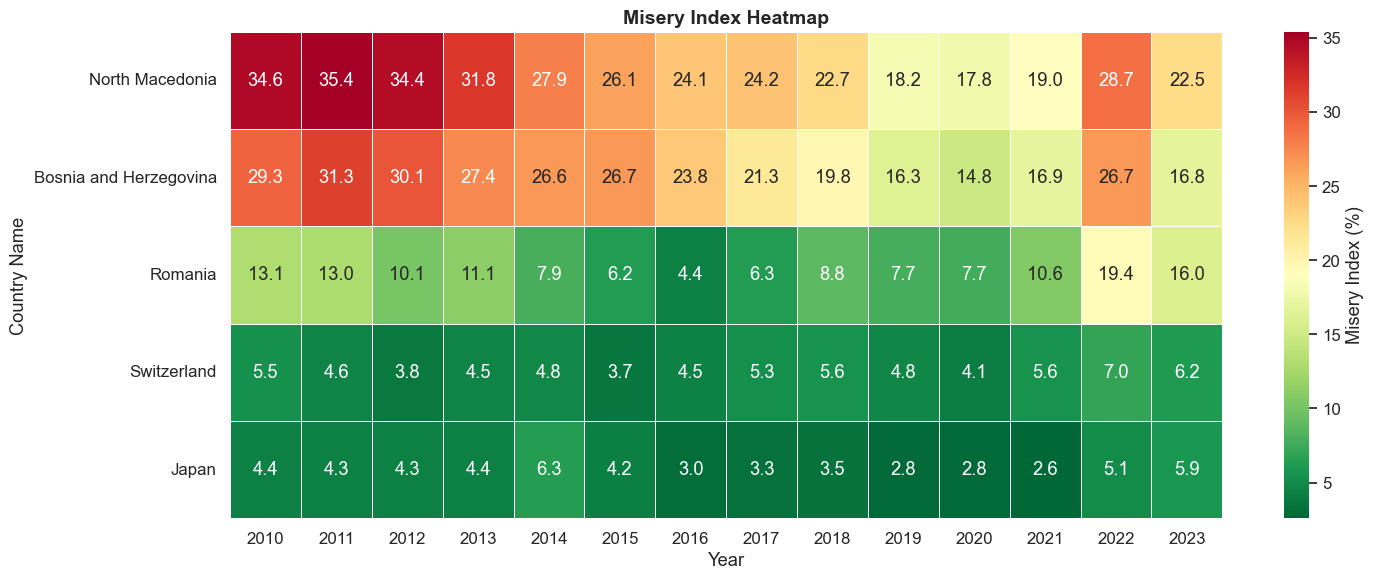

In [16]:
# The Misery Index Heatmap process

temp2 = df_target.copy()

temp2['Misery Index'] = temp2['Unemployment Rate (%)'] + temp2['Inflation (CPI %)']
misery_index_avg = temp2.groupby('country_name')['Misery Index'].mean().sort_values(ascending=False)

highest_misery = misery_index_avg.head(2).index.tolist()
overall_median = misery_index_avg.median()
average_misery_country = (misery_index_avg - overall_median).abs().sort_values().head(1).index.tolist()
lowest_misery = misery_index_avg.tail(2).index.tolist()
selected_countries = highest_misery + average_misery_country + lowest_misery

df_subset_misery = temp2[temp2['country_name'].isin(selected_countries)]

df_misery_pivot = df_subset_misery.pivot_table(index='country_name', columns='year', values='Misery Index')
df_misery_pivot = df_misery_pivot.reindex(highest_misery + average_misery_country + lowest_misery)

plt.figure(figsize=(15, 6))
sns.heatmap(df_misery_pivot, cmap='RdYlGn_r', annot=True, fmt=".1f", linewidths=.5, cbar_kws={'label': 'Misery Index (%)'})
plt.title('Misery Index Heatmap', fontsize=14, fontweight='bold')
plt.ylabel('Country Name')
plt.xlabel('Year')
plt.tight_layout()
plt.show()



<h3 style="font-size:30px; color:green;">This heatmap shows:</h3>

* The highest two countries in misery index (North Macedonia & Bosnia and Herzegovina)
* The median country in misery index (Romania)
* The lowest two countries in misery index (Switzerland & Japan)

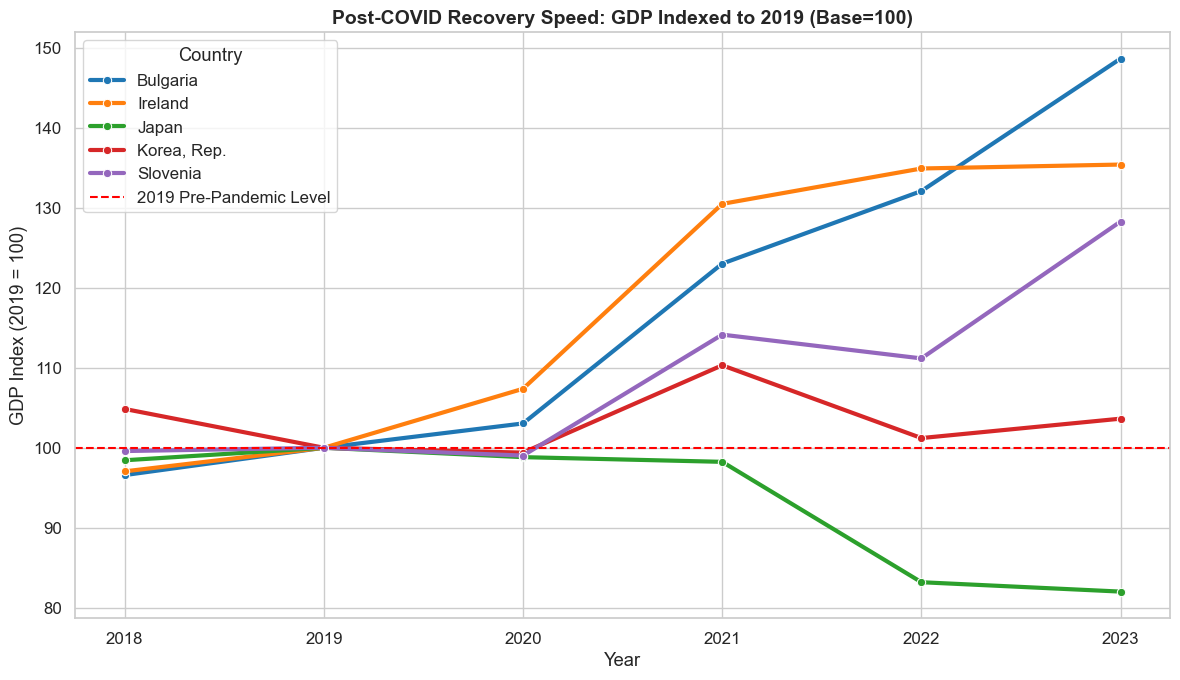

In [17]:
# Post-COVID Recovery Speed process

# the GDP Index (2019=100) 
temp = df_target.copy()

temp['GDP_Index'] = 0.0
for country in temp['country_name'].unique():
    base_gdp_data = temp[(temp['country_name'] == country) & (temp['year'] == 2019)]['GDP (Current USD)']
    if not base_gdp_data.empty:
        base_gdp = base_gdp_data.values[0]
        temp.loc[temp['country_name'] == country, 'GDP_Index'] = \
            (temp.loc[temp['country_name'] == country, 'GDP (Current USD)'] / base_gdp) * 100

df_recovery_period = temp[temp['year'] >= 2020]
recovery_index_avg = df_recovery_period.groupby('country_name')['GDP_Index'].mean().sort_values(ascending=False)

highest_recovery = recovery_index_avg.head(2).index.tolist()
overall_mean_recovery = recovery_index_avg.median()
average_recovery_country = (recovery_index_avg - overall_mean_recovery).abs().sort_values().head(1).index.tolist()
lowest_recovery = recovery_index_avg.tail(2).index.tolist()
selected_recovery_countries = highest_recovery + average_recovery_country + lowest_recovery

df_subset_recovery = temp[temp['country_name'].isin(selected_recovery_countries)]
df_plot_data = df_subset_recovery[df_subset_recovery['year'] >= 2018]

plt.figure(figsize=(12, 7))
sns.lineplot(data=df_plot_data, x='year', y='GDP_Index', hue='country_name', linewidth=3, marker='o')
plt.axhline(100, color='red', linestyle='--', label='2019 Pre-Pandemic Level')
plt.title('Post-COVID Recovery Speed: GDP Indexed to 2019 (Base=100)', fontsize=14, fontweight='bold')
plt.ylabel('GDP Index (2019 = 100)')
plt.xlabel('Year')
plt.legend(title='Country', loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


<h3 style="font-size:30px; color:green;">This graph shows:</h3>

* The highest two countries in recovery speed (Bulgaria & Ireland)
* The median country in recovery speed (Slovenia)
* The lowest two countries in recovery speed (South Korea & Japan)

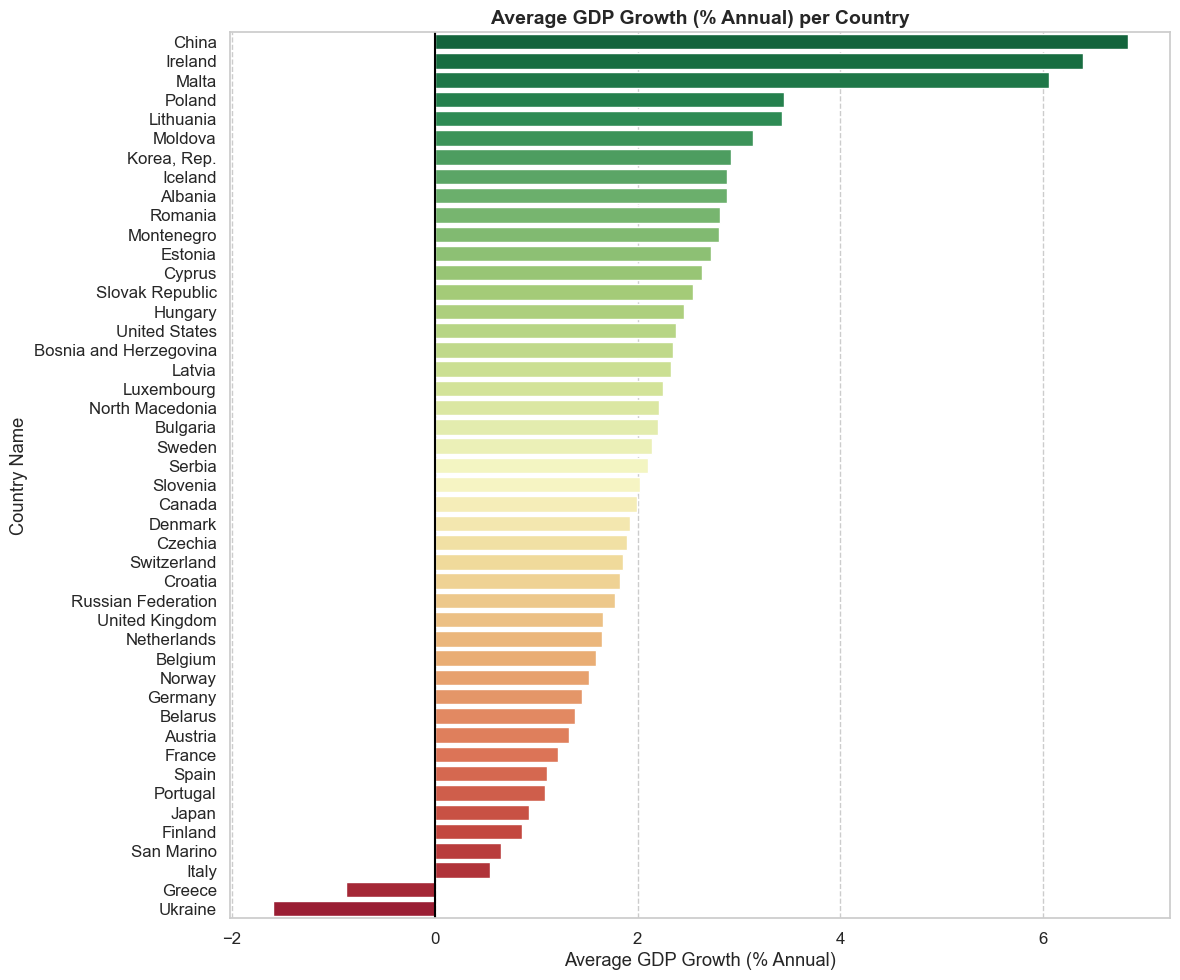

In [18]:
# The Average GDP Growth barplot process


gdp_growth_avg = df_target.groupby('country_name')['GDP Growth (% Annual)'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 10))

ax = sns.barplot(data=gdp_growth_avg, x='GDP Growth (% Annual)', y='country_name', hue='country_name', palette='RdYlGn_r')

plt.title('Average GDP Growth (% Annual) per Country', fontsize=14, fontweight='bold')
plt.xlabel('Average GDP Growth (% Annual)')
plt.ylabel('Country Name')
plt.grid(axis='x', linestyle='--')
plt.axvline(0, color='black', linestyle='-') 
if ax.get_legend():
    ax.legend_.remove()

plt.savefig("Average_GDP_Growth.jpg", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

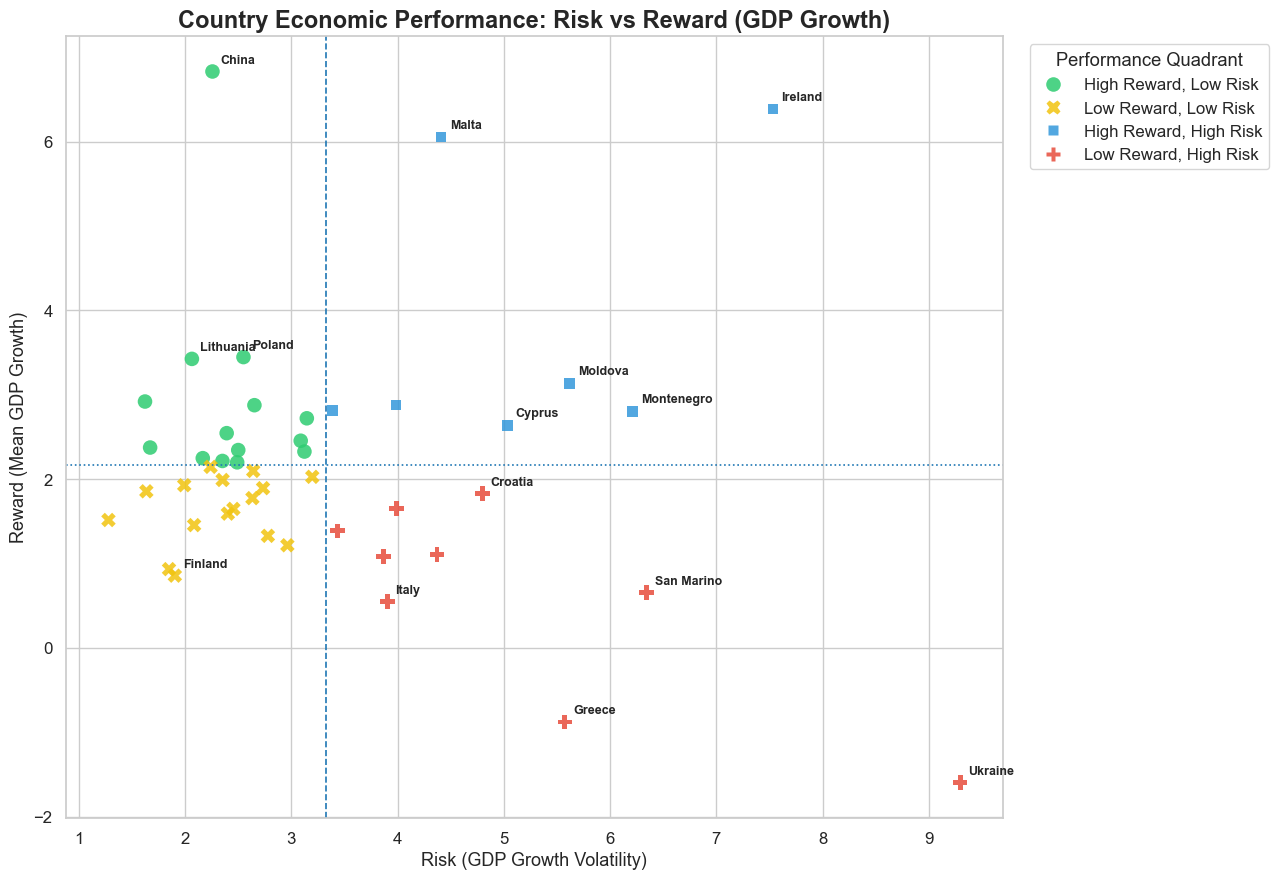

In [19]:
# The Risk vs Reward (GDP Growth) graph process

risk_reward_df = (df_target.groupby('country_name')['GDP Growth (% Annual)'].agg(Mean_GDP_Growth='mean',Std_GDP_Growth='std').reset_index())

mean_reward = risk_reward_df['Mean_GDP_Growth'].mean()
mean_risk   = risk_reward_df['Std_GDP_Growth'].mean()

def assign_quadrant(row):
    if row['Mean_GDP_Growth'] >= mean_reward and row['Std_GDP_Growth'] < mean_risk:
        return 'High Reward, Low Risk'
    elif row['Mean_GDP_Growth'] < mean_reward and row['Std_GDP_Growth'] < mean_risk:
        return 'Low Reward, Low Risk'
    elif row['Mean_GDP_Growth'] >= mean_reward and row['Std_GDP_Growth'] >= mean_risk:
        return 'High Reward, High Risk'
    else:
        return 'Low Reward, High Risk'

risk_reward_df['Quadrant'] = risk_reward_df.apply(assign_quadrant, axis=1)

quadrant_order = ['High Reward, Low Risk','Low Reward, Low Risk','High Reward, High Risk','Low Reward, High Risk']

risk_reward_df['Quadrant'] = pd.Categorical(risk_reward_df['Quadrant'],categories=quadrant_order,ordered=True)

risk_reward_df = risk_reward_df.sort_values('Quadrant')

plt.figure(figsize=(13, 9))

sns.scatterplot(data=risk_reward_df,x='Std_GDP_Growth',y='Mean_GDP_Growth',hue='Quadrant',style='Quadrant',s=110,alpha=0.85,edgecolor='none',
    palette={
        'High Reward, Low Risk': '#2ecc71',
        'Low Reward, Low Risk': '#f1c40f',
        'High Reward, High Risk': '#3498db',
        'Low Reward, High Risk': '#e74c3c'
    }
)


plt.axvline(mean_risk, linestyle='--', linewidth=1.2)
plt.axhline(mean_reward, linestyle=':', linewidth=1.2)


for i, row in risk_reward_df.iterrows():
    if (
        row['Std_GDP_Growth'] > mean_risk * 1.4 or
        row['Mean_GDP_Growth'] > mean_reward * 1.4 or
        row['Mean_GDP_Growth'] < mean_reward * 0.4
    ):
        plt.annotate(row['country_name'],
            (row['Std_GDP_Growth'], row['Mean_GDP_Growth']),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=9,
            fontweight='bold'
        )

plt.title('Country Economic Performance: Risk vs Reward (GDP Growth)', fontsize=17,fontweight='bold')

plt.xlabel('Risk (GDP Growth Volatility)', fontsize=13)
plt.ylabel('Reward (Mean GDP Growth)', fontsize=13)

plt.legend(title='Performance Quadrant',bbox_to_anchor=(1.02, 1),loc='upper left',frameon=True)

plt.savefig("Risk vs Reward (GDP Growth).jpg", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

<h3 style="font-size:30px; color:green;">This graph shows some countries that have: </h3>

* High Reward & Low Risk: China
* Low Reward & Low Risk: Finland
* High Reward & High Risk: Ireland
* Low Reward & High Risk: Ukraine

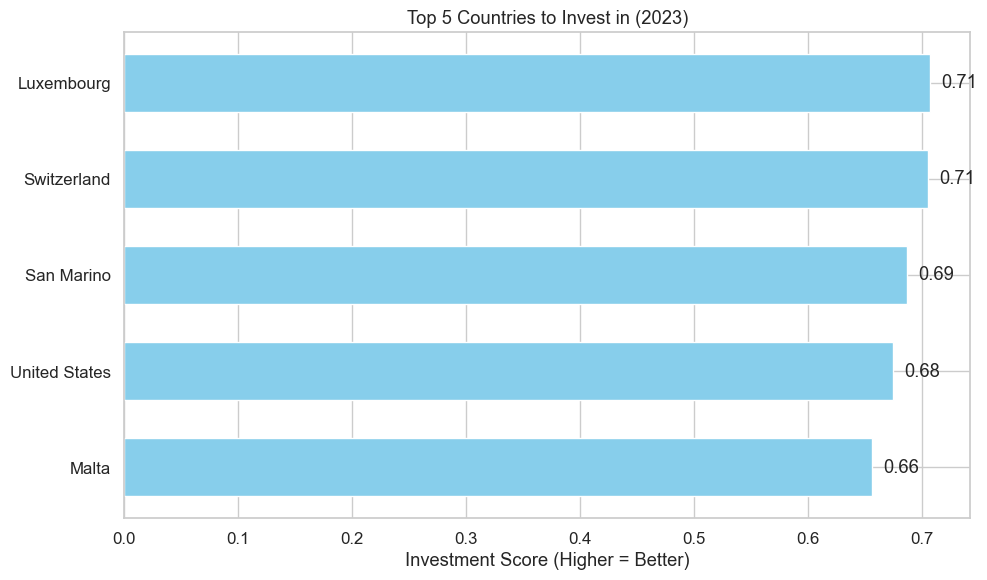

In [20]:
cols = ["country_name", "year", "GDP per Capita (Current USD)", "GDP Growth (% Annual)", "Inflation (CPI %)"]
df_invest = df_target[cols]

# Focus on latest year
latest_year = df_invest['year'].max()
df_latest = df_invest[df_invest['year'] == latest_year].copy()

# Normalize metrics
scaler = MinMaxScaler()
df_latest[["GDP_per_Capita_norm", "GDP_Growth_norm"]] = scaler.fit_transform(
    df_latest[["GDP per Capita (Current USD)", "GDP Growth (% Annual)"]]
)
df_latest["Inflation_norm"] = 1 - scaler.fit_transform(df_latest[["Inflation (CPI %)"]])

# Compute combined investment score
df_latest["Investment_Score"] = df_latest[["GDP_per_Capita_norm", "GDP_Growth_norm", "Inflation_norm"]].mean(axis=1)

# Sort countries by score (highest score first)
df_latest.sort_values("Investment_Score", ascending=False, inplace=True)

# Select top 5 countries
df_top5 = df_latest.head(5)

# Plot bar chart with spacing
plt.figure(figsize=(10, 6))
bars = plt.barh(df_top5["country_name"], df_top5["Investment_Score"], color="skyblue", height=0.6)
plt.xlabel("Investment Score (Higher = Better)")
plt.title(f"Top 5 Countries to Invest in ({latest_year})")
plt.gca().invert_yaxis()  # best country on top
plt.tight_layout()  # adjust spacing

# Optional: add score labels to bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f"{width:.2f}", va='center')

plt.show()

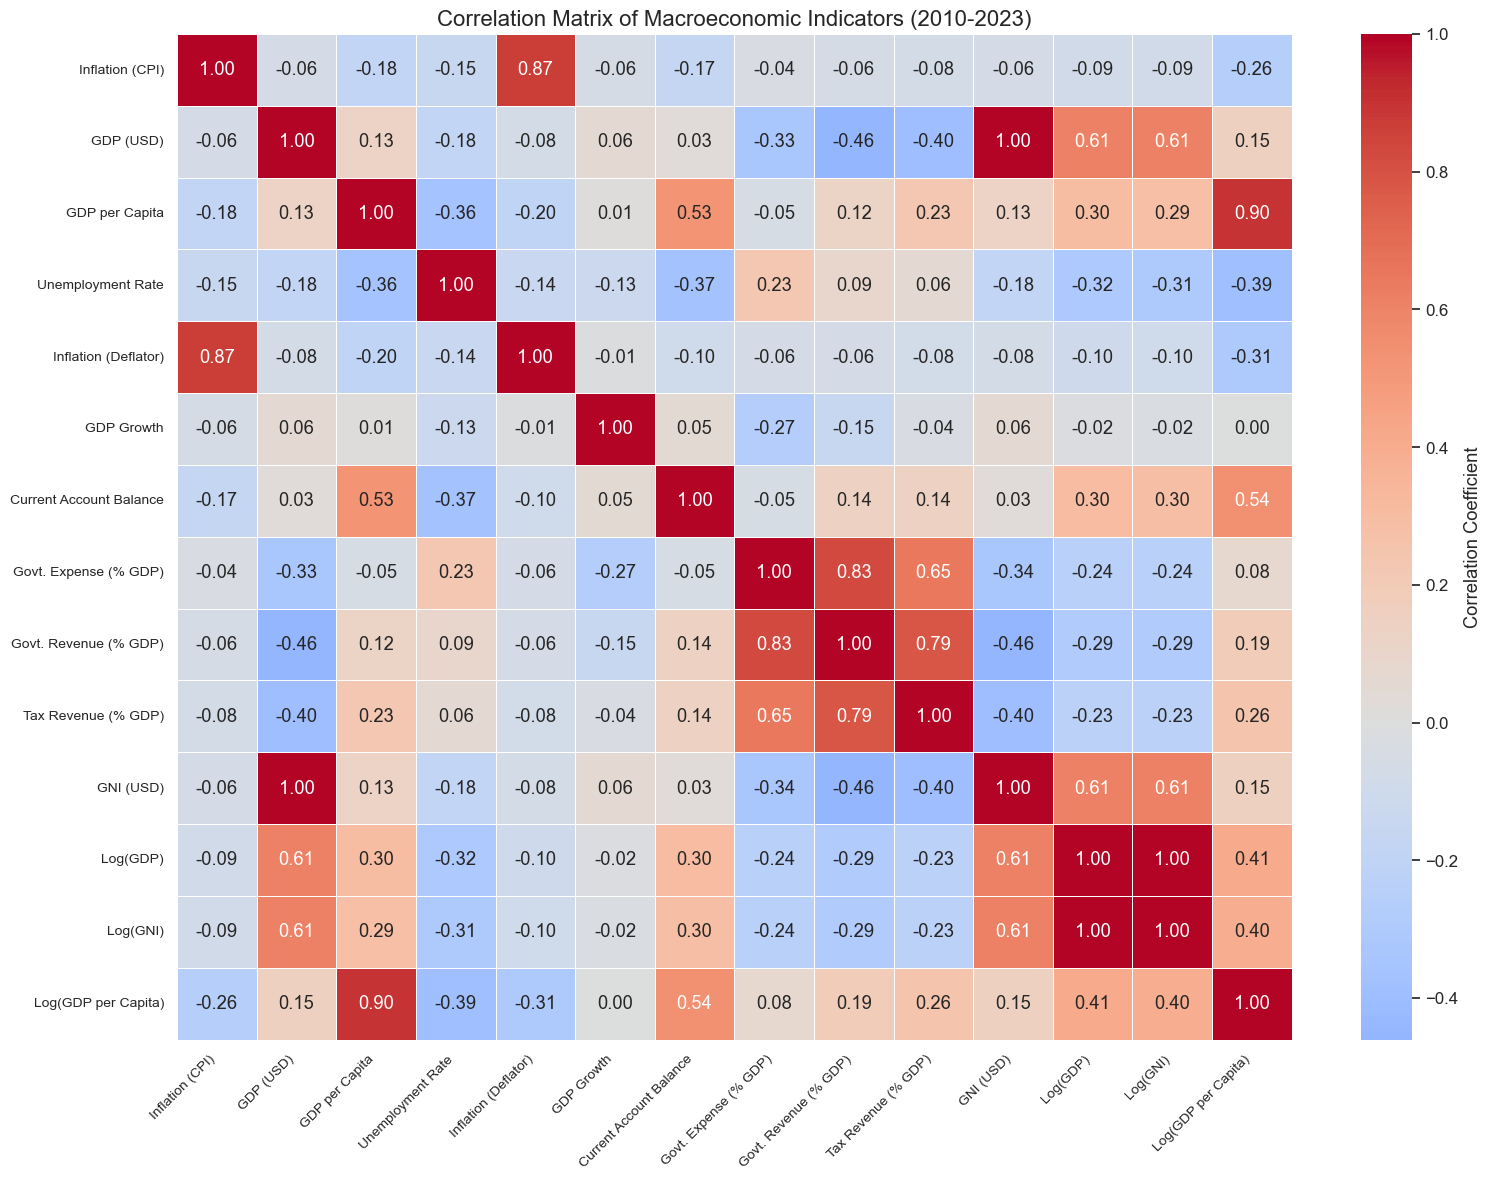

In [21]:
# The correlation matrix process

numeric_df = df_target.select_dtypes(include=np.number).drop(columns=['year'])
correlation_matrix = numeric_df.corr()

readable_columns = {
    'Inflation (CPI %)': 'Inflation (CPI)',
    'GDP (Current USD)': 'GDP (USD)',
    'GDP per Capita (Current USD)': 'GDP per Capita',
    'Unemployment Rate (%)': 'Unemployment Rate',
    'Inflation (GDP Deflator, %)': 'Inflation (Deflator)',
    'GDP Growth (% Annual)': 'GDP Growth',
    'Current Account Balance (% GDP)': 'Current Account Balance',
    'Government Expense (% of GDP)': 'Govt. Expense (% GDP)',
    'Government Revenue (% of GDP)': 'Govt. Revenue (% GDP)',
    'Tax Revenue (% of GDP)': 'Tax Revenue (% GDP)',
    'Gross National Income (USD)': 'GNI (USD)',
    'Log(GDP (Current USD))': 'Log(GDP)',
    'Log(Gross National Income (USD))': 'Log(GNI)',
    'Log(GDP per Capita (Current USD))': 'Log(GDP per Capita)'
}

correlation_matrix.rename(columns=readable_columns, index=readable_columns, inplace=True)
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",          
    cmap='coolwarm',    
    center=0,            
    linewidths=.5,      
    cbar_kws={'label': 'Correlation Coefficient'}
)


plt.title('Correlation Matrix of Macroeconomic Indicators (2010-2023)', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()


<h3 style="font-size:30px; color:green;">This Heatmap shows:</h3>

* A high correlation between **GDP (Current USD) and Gross National Income (USD)**, and similarly between their log-transformed counterparts.
* Good correlations for Government Expense with both Government Revenue & Tax Revenue
* No correlations or moderate correlations for other features

<h2 style="font-size:30px; color:green;">Linear Regression Model</h2>

We used this model to adhere to Occam’s razor principle: **“The simplest explanation is the best explanation.”**

To predict the GDP based on other features.

In [22]:
# Linear Regression model

def run_linear_regression_model(df, features_list, target_name, test_year=2023):
    
    columns_to_select = ['year', 'country_name', target_name] + features_list
    df_target_pred = df[columns_to_select].copy()
    
    df_target_pred = df_target_pred.dropna(subset=columns_to_select).copy()

    X = df_target_pred[features_list]
    y = df_target_pred[target_name]
    years = df_target_pred['year']

    X_train = X[years < test_year]
    X_test = X[years == test_year]
    y_train = y[years < test_year]
    y_test = y[years == test_year]
    df_test_countries = df_target_pred[years == test_year]['country_name']

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    lr_model = LinearRegression()
    lr_model.fit(X_train_scaled, y_train)
    y_pred = lr_model.predict(X_test_scaled)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    feature_print_name = ", ".join(features_list)
    print(f"R-squared (R2) score: {r2:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

    if len(features_list) == 1:
        print(f"Model Coefficient (Slope for {features_list[0]}): {lr_model.coef_[0]:.4f}")
    else:
        print("Model Coefficients (Slopes):")
        for feature, coef in zip(features_list, lr_model.coef_):
            print(f"  {feature}: {coef:.4f}")
            
    print(f"Model Intercept: {lr_model.intercept_:.4f}")

    df_results1 = pd.DataFrame({
        'Country': df_test_countries.values,
        'Year': test_year,
        f'{target_name} Actual': y_test.values,
        f'{target_name} Predicted': y_pred
    })

    plt.figure(figsize=(10, 6))
    plt.scatter(df_results1[f'{target_name} Actual'], df_results1[f'{target_name} Predicted'], alpha=0.7)
    plt.plot(
        [df_results1[f'{target_name} Actual'].min(), df_results1[f'{target_name} Actual'].max()],
        [df_results1[f'{target_name} Actual'].min(), df_results1[f'{target_name} Actual'].max()],
        '--r',
        label='Perfect Prediction Line'
    )
    plt.title(f'Actual vs. Predicted {target_name}')
    plt.xlabel(f'Actual {target_name}')
    plt.ylabel(f'Predicted {target_name}')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.savefig(f'Actual_vs_Predicted_LogGDP_LogGNI.png')
    plt.show()
    return df_results1, lr_model, scaler, r2, mae, mse, rmse

R-squared (R2) score: 0.9986
Mean Absolute Error (MAE): 0.0408
Mean Squared Error (MSE): 0.0060
Root Mean Squared Error (RMSE): 0.0777
Model Coefficient (Slope for Log(Gross National Income (USD))): 2.1134
Model Intercept: 26.0065


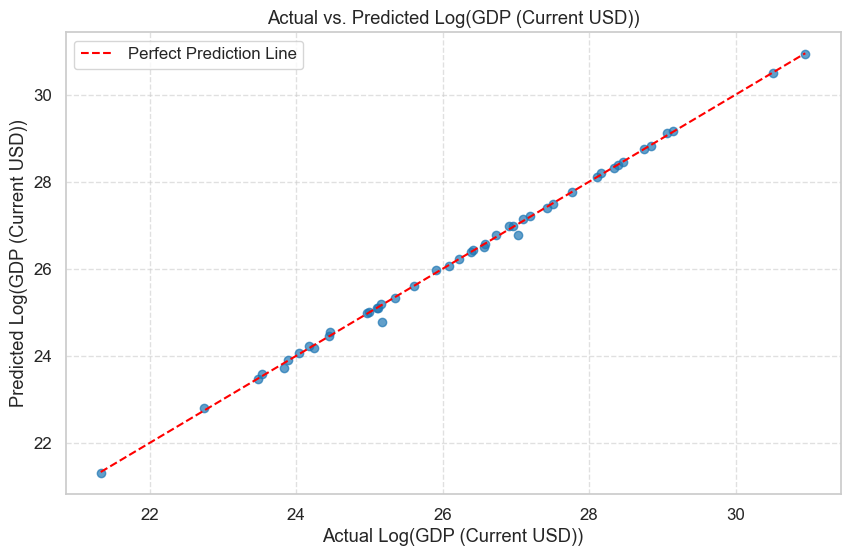

In [23]:
target_name = 'Log(GDP (Current USD))'
features_list = ['Log(Gross National Income (USD))']
df_results, lr_model, scaler, r2, mae, mse, rmse = run_linear_regression_model(
    df=df_target,
    features_list=features_list,
    target_name=target_name
)

<h3 style="font-size:25px; color:green;">Model Evaluation Summary</h3>

Based on the results, the model exhibits a high accuracy rate.
<h4 style="font-size:20px; color:orange;">But</h4>

Predicting the GDP only from GNI does not add a real information to the model because GDP and GNI are definitionally linked (GNI is calculated directly from GDP by adding net income from abroad), making them measures of the same underlying economic scale.

<h4 style="font-size:20px; color:orange;">Some experiments:</h4>

R-squared (R2) score: 0.9988
Mean Absolute Error (MAE): 0.0440
Mean Squared Error (MSE): 0.0052
Root Mean Squared Error (RMSE): 0.0719
Model Coefficients (Slopes):
  Inflation (CPI %): -0.0017
  Unemployment Rate (%): 0.0018
  Inflation (GDP Deflator, %): 0.0085
  GDP Growth (% Annual): 0.0109
  Current Account Balance (% GDP): 0.0046
  Government Expense (% of GDP): 0.0178
  Government Revenue (% of GDP): -0.0181
  Tax Revenue (% of GDP): -0.0097
  Log(Gross National Income (USD)): 2.0952
  Log(GDP per Capita (Current USD)): 0.0374
Model Intercept: 26.0065


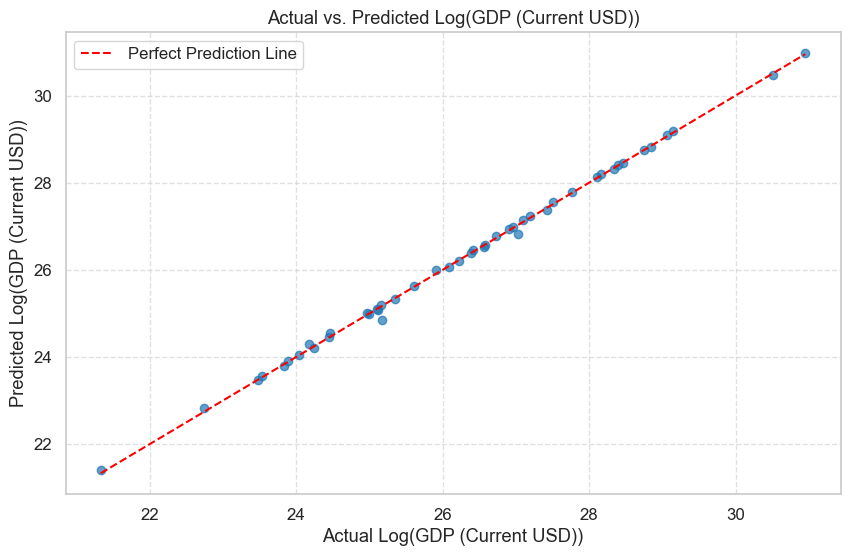

In [24]:
#  All features (including GNI)

target_name = 'Log(GDP (Current USD))'
features_list = [    
    'Inflation (CPI %)',
    'Unemployment Rate (%)',
    'Inflation (GDP Deflator, %)',
    'GDP Growth (% Annual)',
    'Current Account Balance (% GDP)',
    'Government Expense (% of GDP)',
    'Government Revenue (% of GDP)',
    'Tax Revenue (% of GDP)',
    'Log(Gross National Income (USD))',
    'Log(GDP per Capita (Current USD))',
]
df_results, lr_model, scaler, r2, mae, mse, rmse = run_linear_regression_model(
    df=df_target,
    features_list=features_list,
    target_name=target_name
)

R-squared (R2) score: 0.2865
Mean Absolute Error (MAE): 1.3878
Mean Squared Error (MSE): 2.9725
Root Mean Squared Error (RMSE): 1.7241
Model Coefficients (Slopes):
  Inflation (CPI %): 0.0523
  Unemployment Rate (%): -0.2556
  Inflation (GDP Deflator, %): -0.0616
  GDP Growth (% Annual): -0.1057
  Current Account Balance (% GDP): 0.3520
  Government Expense (% of GDP): 0.4922
  Government Revenue (% of GDP): -1.0655
  Tax Revenue (% of GDP): -0.2055
  Log(GDP per Capita (Current USD)): 0.7898
Model Intercept: 26.0065


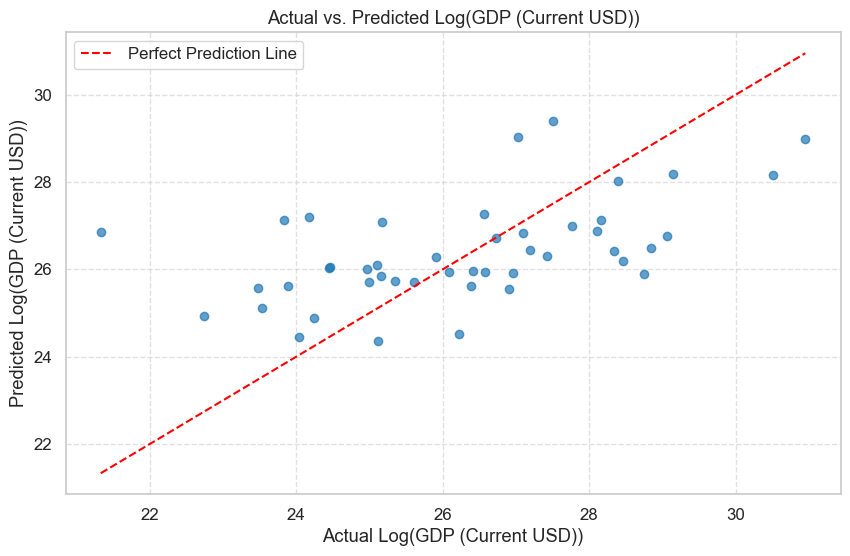

In [25]:
#  All features (without GNI)

target_name = 'Log(GDP (Current USD))'
features_list = [    
    'Inflation (CPI %)',
    'Unemployment Rate (%)',
    'Inflation (GDP Deflator, %)',
    'GDP Growth (% Annual)',
    'Current Account Balance (% GDP)',
    'Government Expense (% of GDP)',
    'Government Revenue (% of GDP)',
    'Tax Revenue (% of GDP)',
    'Log(GDP per Capita (Current USD))',
]
df_results, lr_model, scaler, r2, mae, mse, rmse = run_linear_regression_model(
    df=df_target,
    features_list=features_list,
    target_name=target_name
)

R-squared (R2) score: 0.2212
Mean Absolute Error (MAE): 1.4862
Mean Squared Error (MSE): 3.2449
Root Mean Squared Error (RMSE): 1.8014
Model Coefficients (Slopes):
  Inflation (CPI %): -0.1829
  Unemployment Rate (%): -0.4979
  GDP Growth (% Annual): -0.1375
  Current Account Balance (% GDP): 0.6430
  Government Expense (% of GDP): 0.5816
  Government Revenue (% of GDP): -1.1585
  Tax Revenue (% of GDP): -0.0324
Model Intercept: 26.0065


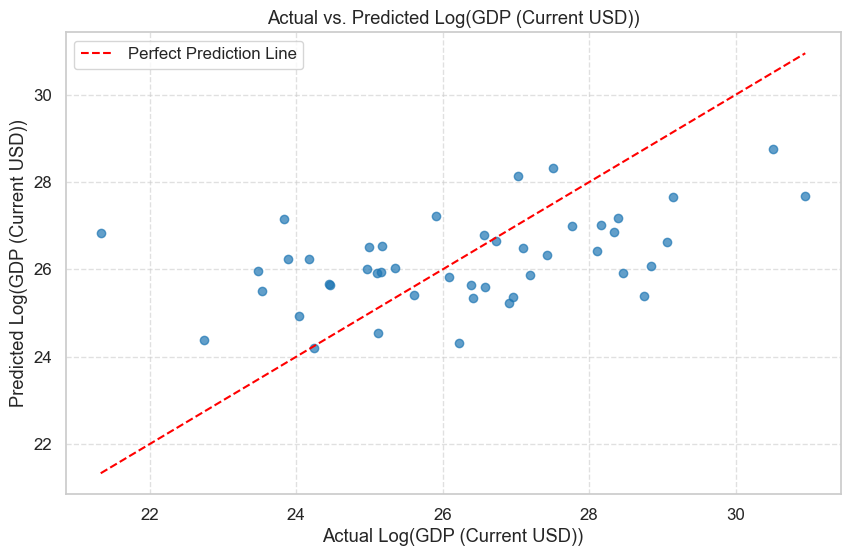

In [26]:
# Many features without GNI

target_name = 'Log(GDP (Current USD))'
features_list = [    
    'Inflation (CPI %)',
    'Unemployment Rate (%)',
    'GDP Growth (% Annual)',
    'Current Account Balance (% GDP)',
    'Government Expense (% of GDP)',
    'Government Revenue (% of GDP)',
    'Tax Revenue (% of GDP)',
]
df_results, lr_model, scaler, r2, mae, mse, rmse = run_linear_regression_model(
    df=df_target,
    features_list=features_list,
    target_name=target_name
)

R-squared (R2) score: 0.0704
Mean Absolute Error (MAE): 1.5975
Mean Squared Error (MSE): 3.8729
Root Mean Squared Error (RMSE): 1.9680
Model Coefficient (Slope for Unemployment Rate (%)): -0.6720
Model Intercept: 26.0065


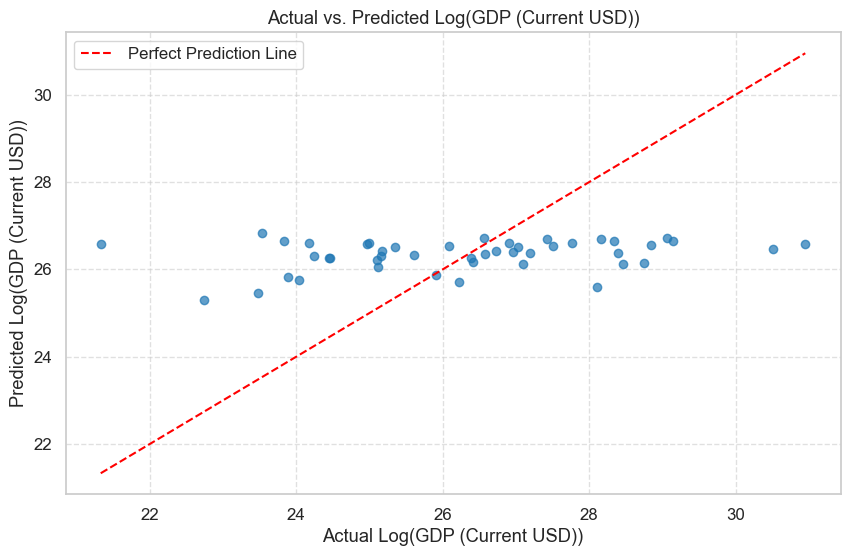

In [27]:
# Feature: Unemployment Rate (%)

target_name = 'Log(GDP (Current USD))'
features_list = ['Unemployment Rate (%)']
df_results, lr_model, scaler, r2, mae, mse, rmse = run_linear_regression_model(
    df=df_target,
    features_list=features_list,
    target_name=target_name
)

R-squared (R2) score: -0.0006
Mean Absolute Error (MAE): 1.6872
Mean Squared Error (MSE): 4.1689
Root Mean Squared Error (RMSE): 2.0418
Model Coefficient (Slope for Inflation (CPI %)): -0.1720
Model Intercept: 26.0065


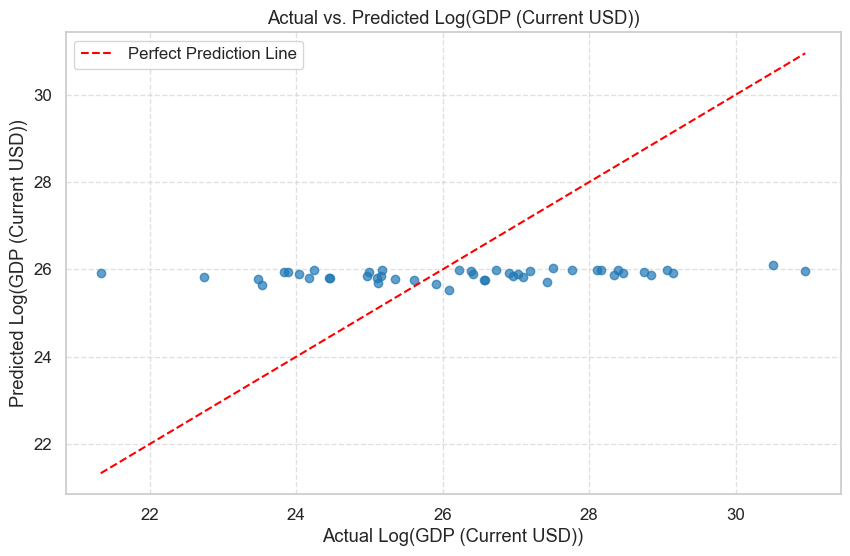

In [28]:
# Feature: Inflation (CPI %)

target_name = 'Log(GDP (Current USD))'
features_list = ['Inflation (CPI %)']
df_results, lr_model, scaler, r2, mae, mse, rmse = run_linear_regression_model(
    df=df_target,
    features_list=features_list,
    target_name=target_name
)

R-squared (R2) score: 0.1268
Mean Absolute Error (MAE): 1.5571
Mean Squared Error (MSE): 3.6382
Root Mean Squared Error (RMSE): 1.9074
Model Coefficients (Slopes):
  Inflation (CPI %): -0.2651
  Unemployment Rate (%): -0.7069
Model Intercept: 26.0065


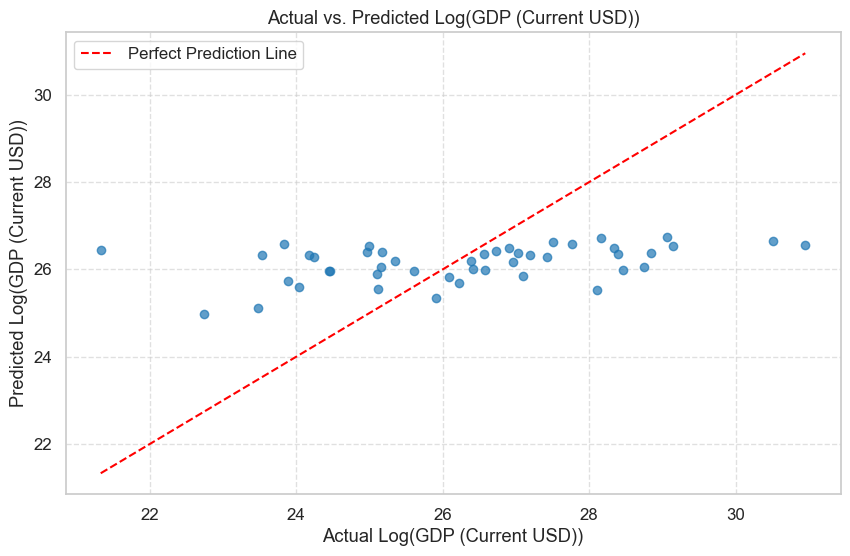

In [29]:
# Features: Inflation (CPI %)', 'Unemployment Rate (%)


target_name = 'Log(GDP (Current USD))'
features_list = ['Inflation (CPI %)', 'Unemployment Rate (%)']
df_results, lr_model, scaler, r2, mae, mse, rmse = run_linear_regression_model(
    df=df_target,
    features_list=features_list,
    target_name=target_name
)

R-squared (R2) score: 0.1075
Mean Absolute Error (MAE): 1.5758
Mean Squared Error (MSE): 3.7185
Root Mean Squared Error (RMSE): 1.9284
Model Coefficients (Slopes):
  GDP Growth (% Annual): -0.2496
  Inflation (CPI %): -0.1923
  Unemployment Rate (%): -0.4508
  Current Account Balance (% GDP): 0.4616
  Government Expense (% of GDP): -0.4719
Model Intercept: 26.0065


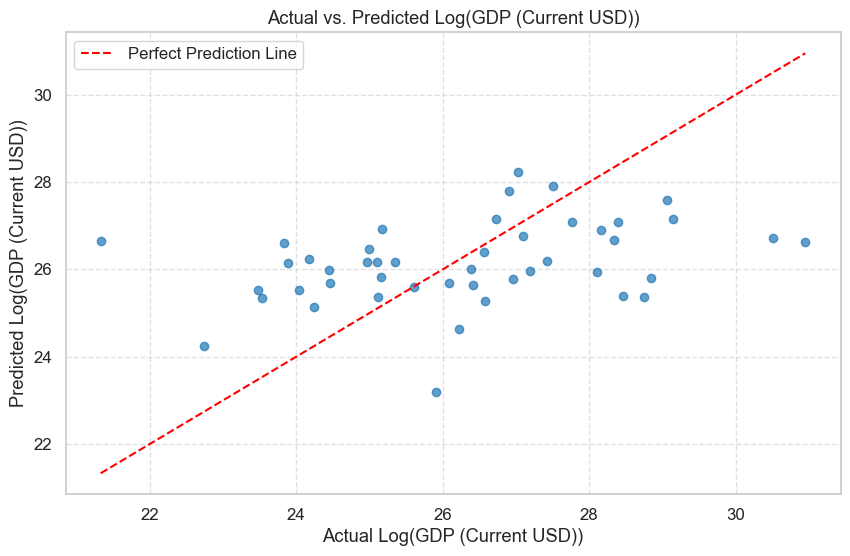

In [30]:
# Some features without GNI

target_name = 'Log(GDP (Current USD))'
features_list = [    
    'GDP Growth (% Annual)',
    'Inflation (CPI %)',
    'Unemployment Rate (%)',
    'Current Account Balance (% GDP)',
    'Government Expense (% of GDP)'
]

df_results, lr_model, scaler, r2, mae, mse, rmse = run_linear_regression_model(
    df=df_target,
    features_list=features_list,
    target_name=target_name
)

R-squared (R2) score: 0.9986
Mean Absolute Error (MAE): 0.0426
Mean Squared Error (MSE): 0.0058
Root Mean Squared Error (RMSE): 0.0760
Model Coefficients (Slopes):
  GDP Growth (% Annual): 0.0089
  Inflation (CPI %): -0.0017
  Unemployment Rate (%): -0.0058
  Current Account Balance (% GDP): 0.0128
  Log(Gross National Income (USD)): 2.1084
  Government Expense (% of GDP): 0.0036
Model Intercept: 26.0065


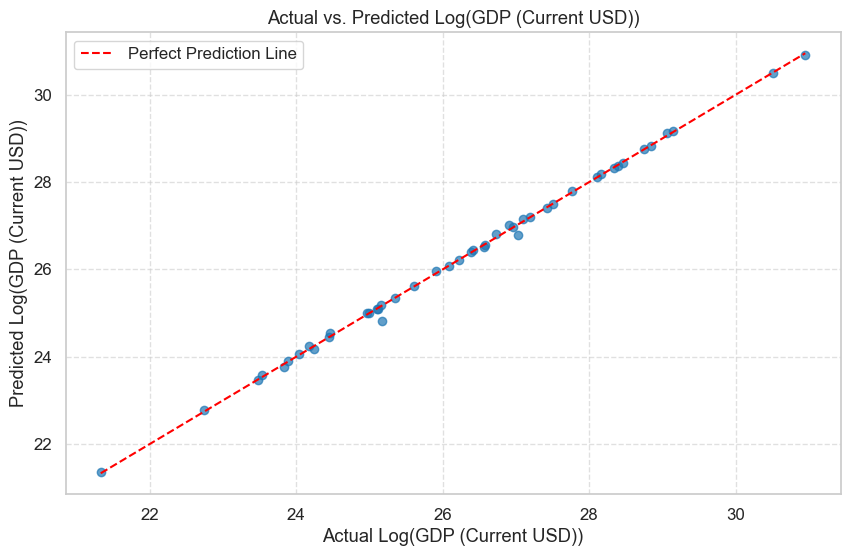

In [31]:
# Some features with GNI


target_name = 'Log(GDP (Current USD))'
features_list = [    
    'GDP Growth (% Annual)',
    'Inflation (CPI %)',
    'Unemployment Rate (%)',
    'Current Account Balance (% GDP)',
    'Log(Gross National Income (USD))',
    'Government Expense (% of GDP)'
]
df_results, lr_model, scaler, r2, mae, mse, rmse = run_linear_regression_model(
    df=df_target,
    features_list=features_list,
    target_name=target_name
)

<h4 style="font-size:20px; color:orange;">Some experiments but the target is GDP Growth:</h4>
We used the previous year (t−1) as input features to predict GDP Growth in the current year (t).

---- MODEL RESULTS ----
R²:   -0.1589
MAE:  2.0253
RMSE: 2.6868


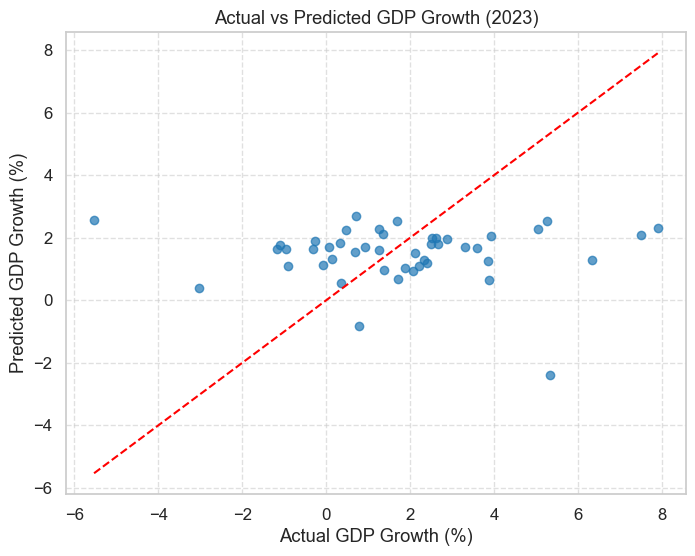

In [32]:
features = [
    'GDP Growth (% Annual)',
    'Inflation (CPI %)',
    'Unemployment Rate (%)',
    'Current Account Balance (% GDP)',
    'Government Expense (% of GDP)'
]

df_model = df_target[['country_name', 'year'] + features].copy()

df_model = df_model.sort_values(['country_name', 'year'])

for col in features:
    df_model[f'{col}_lag1'] = (df_model.groupby('country_name')[col].shift(1))

target = 'GDP Growth (% Annual)'
lagged_features = [f'{col}_lag1' for col in features]

df_model_final = df_model.dropna(subset=[target] + lagged_features).copy()


test_year = 2023

train_df = df_model_final[df_model_final['year'] < test_year]
test_df  = df_model_final[df_model_final['year'] == test_year]

X_train = train_df[lagged_features]
y_train = train_df[target]

X_test = test_df[lagged_features]
y_test = test_df[target]
countries_test = test_df['country_name']


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)


r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("---- MODEL RESULTS ----")
print(f"R²:   {r2:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")


plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         '--r')
plt.xlabel("Actual GDP Growth (%)")
plt.ylabel("Predicted GDP Growth (%)")
plt.title("Actual vs Predicted GDP Growth (2023)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [33]:
#Cross-validation

target = 'GDP Growth (% Annual)'
features = [
    'Inflation (CPI %)_lag1',
    'Unemployment Rate (%)_lag1',
    'Current Account Balance (% GDP)_lag1',
    'Government Expense (% of GDP)_lag1'
]

df_cv = df_model_final[['country_name', 'year', target] + features].copy()

def time_series_cv(df, model, feature_cols, target_col, start_year=2015):
    
    results = []

    years = sorted(df['year'].unique())
    test_years = [y for y in years if y >= start_year]

    for test_year in test_years:
        train_df = df[df['year'] < test_year]
        test_df  = df[df['year'] == test_year]

        if len(test_df) == 0:
            continue

        X_train = train_df[feature_cols]
        y_train = train_df[target_col]
        X_test  = test_df[feature_cols]
        y_test  = test_df[target_col]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled  = scaler.transform(X_test)

        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

        results.append({
            'Test Year': test_year,
            'R2': r2_score(y_test, y_pred),
            'MAE': mean_absolute_error(y_test, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_test, y_pred))
        })

    return pd.DataFrame(results)


<h3>We apply cross-validation by year and compare the performance of
Linear Regression, Ridge, and Lasso models.</h3> 

In [34]:
# Ridge & Lasso

from sklearn.linear_model import Ridge, Lasso

models = {
    'Linear Regression': LinearRegression(),
    'Ridge (α=1.0)': Ridge(alpha=1.0),
    'Lasso (α=0.05)': Lasso(alpha=0.05, max_iter=5000)
}

cv_results = {}

for name, model in models.items():
    cv_results[name] = time_series_cv(
        df=df_cv,
        model=model,
        feature_cols=features,
        target_col=target,
        start_year=2016
    )

summary = []

for model_name, res in cv_results.items():
    summary.append({
        'Model': model_name,
        'Mean R2': res['R2'].mean(),
        'Mean MAE': res['MAE'].mean(),
        'Mean RMSE': res['RMSE'].mean()
    })

summary_df = pd.DataFrame(summary).sort_values(by='Mean RMSE')
print(summary_df)

scaler = StandardScaler()
X = df_cv[features]
y = df_cv[target]

X_scaled = scaler.fit_transform(X)

ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.05, max_iter=5000)

ridge.fit(X_scaled, y)
lasso.fit(X_scaled, y)

coef_compare = pd.DataFrame({
    'Feature': features,
    'Ridge Coef': ridge.coef_,
    'Lasso Coef': lasso.coef_
})

print(coef_compare)


               Model   Mean R2  Mean MAE  Mean RMSE
2     Lasso (α=0.05) -1.054427  3.029969   3.853884
1      Ridge (α=1.0) -1.087949  3.057820   3.880541
0  Linear Regression -1.088994  3.058667   3.881306
                                Feature  Ridge Coef  Lasso Coef
0                Inflation (CPI %)_lag1   -0.462616   -0.401983
1            Unemployment Rate (%)_lag1   -0.155525   -0.103468
2  Current Account Balance (% GDP)_lag1   -0.010904    0.000000
3    Government Expense (% of GDP)_lag1   -0.198903   -0.156972
